<a href="https://colab.research.google.com/github/k6jf8wfhxh-ux/jdla-e-shikaku-study/blob/main/lecture07_exercise_answer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 第7回講義 演習

本演習ではPyTorchを使用し，基本的な回帰結合型ニューラルネット(RNN)と，その一種である長短期記憶(LSTM)を実装し，文章の分類タスクを解いていきます．

[IMDb (Internet Movie Database)](https://huggingface.co/datasets/stanfordnlp/imdb) と呼ばれるデータセットには，映画のレビュー文とその評価についてpositiveかnegativeか記録されています．

<div style="text-align: center;">【データセットのイメージ】</div>

| レビュー | 評価 |
|:--------:|:-------------:|
|Where's Michael Caine when you need him? I've ...|0|
|To experience Head you really need to understa...|1|

0 = negative, 1 = positive

そこで各レビュー文を入力として，その評価positive/negativeの二値分類をRNNで行ってみましょう．  

---

# Lecture 7 Exercises

In this exercise, we use PyTorch to implement a basic recurrent neural network (RNN) and its variant, the long short-term memory (LSTM), and solve a text classification task.

The dataset called [IMDb (Internet Movie Database)](https://huggingface.co/datasets/stanfordnlp/imdb) contains movie reviews and their sentiment labels (positive or negative).

<div style="text-align: center;">【Dataset Overview】</div>

| Review | Label |
|:------:|:-----:|
| Where's Michael Caine when you need him? I've ... | 0 |
| To experience Head you really need to understa... | 1 |

0 = negative, 1 = positive  

Using each review as input, we will perform binary classification (positive/negative) with an RNN.


## 目次

 [【課題】RNNと派生モデルの実装と学習](#scrollTo=kwLF7moq_PCZ&line=1&uniqifier=1)
1. [データセットの読み込み](#scrollTo=zEltPNkLuLz6)
2. [訓練実行(trainer)関数の定義](#scrollTo=G-laa4YqQRji)
1. Recurrent Neural Network (RNN) によるIMDbのsentiment analysis

    3.1. [Embedding層](#scrollTo=Urh6GUOQKBzE)  

    3.2. [RNN](#scrollTo=ZNPaK9ExKBzI)  

    3.3. [分類器](#scrollTo=2O0bZWqVOVk0)

    3.4. [学習](#scrollTo=emiO4f5rCklA)

    3.5. [torch.nn.RNN, torch.nn.Embeddingを用いたネットワークの記述](#scrollTo=yCktWJ9N8QDN)

1. Long short-term memory (LSTM) によるIMDbのsentiment analysis

    4.1. [LSTM](#scrollTo=tsXtYkNEm1Bh)

    4.2. [分類器](#scrollTo=IfHaLvJJWHeI)

    4.3. [学習](#scrollTo=qR2iKUy7yA3R)

    4.4. [torch.nn.LSTMを用いたネットワークの記述](#scrollTo=thf8W0lywagD)

5. Bidirectional LSTM

    5.1. [BidirectionalLSTM](#scrollTo=L9ZNn5gTP2yH)

    5.2. [学習](#scrollTo=1xbAI25fQA2E)

1. 【補足】[Gradient Clippingによる長系列への対処](#scrollTo=ExuiSiTo2k3m)

---

## Table of Contents

- [Task: Implement and Train RNNs and Derived Models](#scrollTo=kwLF7moq_PCZ&line=1&uniqifier=1)
1. [Load the Dataset](#scrollTo=zEltPNkLuLz6)
2. [Define the Training Loop (`trainer`) Function](#scrollTo=G-laa4YqQRji)
3. IMDb sentiment analysis with a Recurrent Neural Network (RNN)

    3.1. [Embedding Layer](#scrollTo=Urh6GUOQKBzE)  

    3.2. [RNN](#scrollTo=ZNPaK9ExKBzI)  

    3.3. [Classifier](#scrollTo=2O0bZWqVOVk0)

    3.4. [Training](#scrollTo=emiO4f5rCklA)

    3.5. [Build a Network with `torch.nn.RNN` and `torch.nn.Embedding`](#scrollTo=yCktWJ9N8QDN)

4. IMDb sentiment analysis with Long Short-Term Memory (LSTM)

    4.1. [LSTM](#scrollTo=tsXtYkNEm1Bh)

    4.2. [Classifier](#scrollTo=IfHaLvJJWHeI)

    4.3. [Training](#scrollTo=qR2iKUy7yA3R)

    4.4. [Build a Network with `torch.nn.LSTM`](#scrollTo=thf8W0lywagD)

5. Bidirectional LSTM

    5.1. [Bidirectional LSTM](#scrollTo=L9ZNn5gTP2yH)


In [ ]:
!pip install portalocker
!pip install datasets==3.6.0

import random
import numpy as np
import string
import re
import string
from collections import Counter
from typing import List
import torch
import torch.nn as nn
import torch.optim as optim
import torch.autograd as autograd
from torch.utils.data import DataLoader,random_split
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence
from sklearn.metrics import f1_score
from datasets import load_dataset
import nltk
from nltk.probability import FreqDist

nltk.download('punkt_tab')
seed = 1234
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
random.seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 16.7 MB/s eta 0:00:00
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


## 【課題】RNNと派生モデルの実装と学習

---

## Task: Implement and Train RNNs and Derived Models


## 1.データセットの読み込み

自然言語処理において，データとなる文をそのままネットワークに入力することは出来ないので，適切な前処理をする必要があります．

前処理の手順（英文の場合）は大まかに，
- 単語ごとに区切る
- 各単語にIDを割り振る

という手順で行われ，この手順を経ることで，元々の文は整数列に変換され，ネットワークに入力することが可能となります．

また，本演習では各単語にIDを割り振る処理に`NLTK`と呼ばれるライブラリを用いています．詳しく知りたい方は，[公式ドキュメント](https://www.nltk.org/api/nltk.html)を参照してください．

---

## 1. Load the Dataset

In natural language processing, we cannot feed raw sentences directly into a neural network, so we need appropriate preprocessing.

For English text, the preprocessing pipeline is roughly:
- Split the sentence into words (tokenization)
- Assign an ID to each word

After these steps, the original sentence is converted into a sequence of integers, which can be fed into the network.

In this exercise, we use a library called `NLTK` to assign IDs to words. If you want to learn more, refer to the [official documentation](https://www.nltk.org/api/nltk.html).


In [ ]:
# Helper function to prevent NaNs from torch.log(0)
#
def torch_log(x):
    return torch.log(torch.clamp(x, min=1e-10))

In [ ]:
# Download the IMDB dataset
# If prompted for a token, note that an HF token is not required to download this dataset—click Cancel
print("Loading IMDB dataset...")
dataset = load_dataset("stanfordnlp/imdb")
# Split the data
train_data, valid_data = random_split(
    dataset['train'], [20000, 5000],
    )
test_data = dataset['test']

Loading IMDB dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

[nltk.probability.FreqDist](https://www.nltk.org/api/nltk.probability.html#nltk.probability.FreqDist)で訓練データの文章内の単語を数え上げ，語彙リスト（`FreqDist`オブジェクト）を作っていきます．

引数`specials`で特別なトークンを指定しています．
- `<unk>`: Unknown. 出てくる頻度が少なすぎる単語などを未分類としておきます．
- `<PAD>`: 短い文章はこのトークンで埋めることで，長い文章に長さを合わせます．
- `<BOS>`: Begin of sentence.
- `<EOS>`: End of sentence.

---

We use [nltk.probability.FreqDist](https://www.nltk.org/api/nltk.probability.html#nltk.probability.FreqDist) to count words in the training sentences and build a vocabulary list (a `FreqDist` object).

We specify special tokens via the `specials` argument:
- `<unk>`: Unknown. Rare words are mapped to this token.
- `<PAD>`: Short sentences are padded with this token to match the length of longer sentences.
- `<BOS>`: Begin of sentence.
- `<EOS>`: End of sentence.


In [ ]:
# Preprocess text: lowercase, remove punctuation (e.g., !"#$%&), split by spaces, etc.
def tokenize(text):
    # 1. Lowercase
    text = text.lower()

    # 2. Remove punctuation (string.punctuation)
    text = ''.join([char for char in text if char not in string.punctuation])

    # 3. Tokenize (split into words)
    tokens = text.split()
    return tokens

In [ ]:
# Create a FreqDist object to count word frequencies
counter = FreqDist()
for i in range(len(train_data)):
    processed = tokenize(train_data[i]["text"])
    # Update frequencies by adding the tokenized word list to FreqDist
    counter.update(processed)

print(f"単語数: {len(counter)}")

単語数: 107344


In [ ]:
# Set <unk> as the default token; words with frequency < min_freq become <unk>
# Apply min_freq and specials
min_freq = 25
specials = ['<unk>', '<PAD>', '<BOS>', '<EOS>']

vocab = specials + [word for word, freq in counter.items() if freq >= min_freq]
vocab_dict = {word: i for i, word in enumerate(vocab)}
word_num = len(vocab_dict)

print(f"単語種数: {word_num}")
print(list(vocab_dict))

単語種数: 10077
['<unk>', '<PAD>', '<BOS>', '<EOS>', 'along', 'with', 'king', 'of', 'the', 'rocket', 'men', 'this', 'was', 'still', 'being', 'repeated', 'on', 'bbc', 'tv', 'in', 'early', 'to', 'mid', 'eighties', 'if', 'i', 'up', 'a', 'time', 'period', 'both', 'these', 'series', 'would', 'definitely', 'go', 'inbr', 'br', 'someone', 'watching', 'it', 'for', 'first', 'will', 'think', 'is', 'silly', 'but', 'one', 'best', 'examples', 'serials', 'don', 'del', 'make', 'you', 'laugh', 'when', 'little', 'my', 'him', 'mr', 'head', 'and', 'funny', 'upon', 'shot', 'at', 'he', 'says', 'your', 'bullets', 'cant', 'harm', 'me', 'then', 'stumbles', 'back', 'seemingly', 'less', 'than', 'happy', 'also', 'like', 'way', 'sebastian', 'episodebr', 'watched', 'again', 'because', 'had', 'good', 'memories', 'from', 'years', 'there', 'are', 'some', 'stunts', 'music', 'has', 'ingredients', 'expect', 'including', 'apart', 'ralph', 'wasnt', 'nearly', 'as', 'remembered', 'yes', 'features', 'inevitable', 'flashback', 'ep

`text_transform()`を`collate_batch()`から呼び，単語のリストを辞書内インデックスのリストに変換します．  

We call `text_transform()` from `collate_batch()` to convert a list of words into a list of indices in the vocabulary.


In [ ]:
# 長さが違う文章に、数字を埋めて長さをそろえる関数（パディング）
def text_transform(_text, max_length=256):
    # If a token is not in vocab_dict, assign 0 (<unk>); subtract 2 to account for <BOS> and <EOS>
    text = [vocab_dict.get(token, 0) for token in tokenize(_text)][:max_length - 2]
    text = [vocab_dict['<BOS>']] + text + [vocab_dict['<EOS>']]
    return text, len(text)

# batch：学習時にデータローダーからまとめて渡される、データのリストを受け取っている
def collate_batch(batch):
  # 空のリストを3つ作成
  # それぞれ「ラベル」「文章データ」「文章の長さ」を格納するための箱
   label_list, text_list, len_seq_list = [], [], []

  # 渡されたbatchリストの中身を1つずつ取り出してループ処理
   for data_point  in list(batch):
      # 現在のデータ（data_point）から「文章」と「ラべル」の内容を取り出して変数に代入
      _text = data_point.get('text')
      _label = data_point.get('label')
      # 取り出したラベルを、ラベル用リストに追加
      label_list.append(_label)

      # text_transform関数を呼び出して、文章を「IDのリスト」に変換し、
      # 同時に「文章の長さ」も取得している
      processed_text, len_seq = text_transform(_text)
      # 変換されたIDのリストをPyTorchのtensor形式に変換してから、文章用リストに追加
      text_list.append(torch.tensor(processed_text))
      # 取得した文章の長さを、長さ用リストに追加
      len_seq_list.append(len_seq)

   return torch.tensor(label_list), pad_sequence(text_list, padding_value=1).T, torch.tensor(len_seq_list)

上で定義した`collate_batch()`を`DataLoader`に渡すことで，バッチに対してその処理を適用することができます．  

By passing the `collate_batch()` function defined above to `DataLoader`, we can apply this preprocessing to each batch.


In [ ]:
batch_size = 128

train_dataloader = DataLoader(
   list(train_data),
   batch_size=batch_size,
   shuffle=True,
   collate_fn=collate_batch
)
valid_dataloader = DataLoader(
   list(valid_data),
   batch_size=batch_size,
   shuffle=False,
   collate_fn=collate_batch
)

## 2.訓練実行(trainer)関数の定義

以降定義するすべてのモデルについて訓練ループは同じなので，ここで関数として実装してしまいます．

---

## 2. Define the Training Loop (`trainer`) Function

Since the training loop is the same for all models we define below, we implement it once as a function here.


In [ ]:
# NOTE: dataloader is in the global scope
# net：学習させるRNNモデル
def train(net, optimizer, n_epochs,):
    # 指定したエポックの数だけ、学習のループを繰り返す
    for epoch in range(n_epochs):
        # 各エポックでの損失（誤差）を記録するためのリストを用意
        losses_train = []
        losses_valid = []

        # モデルを「学習モード」に設定
        # Dropoutなどが有効になる
        net.train()
        n_train = 0
        acc_train = 0
        # train_dataloaderから、バッチを1つずつ取り出す
        for label, line, len_seq in train_dataloader:
          # 前回の計算の勾配を0にする
            net.zero_grad()  # Reset gradients

            # データ（ラベル、文章、長さ）をGPUに転送して高速計算
            t = label.to(device)  # Move tensors to GPU
            x = line.to(device)  # (batch, time)
            len_seq.to(device)

            # モデルに文章（x）と長さ（len_seq）を渡して。推論結果（h）を出力
            h = net(x, torch.max(len_seq), len_seq)
            # RNNの出力をシグモイド関数に通して、0～1の確率値に変換
            y = torch.sigmoid(h).squeeze()

            # 二値分類の交差エントロピー誤差を計算
            loss = -torch.mean(t * torch_log(y) + (1 - t) * torch_log(1 - y))  # WRITE ME

            # 逆伝播
            loss.backward()  # Backpropagate the loss
            # 計算された勾配をもとに、重みを更新
            optimizer.step()  # Update parameters

            # このバッチの損失値を記録
            losses_train.append(loss.tolist())

            # 学習したデータの総数をカウント
            n_train += t.size()[0]

        # 評価コード
        # t_valid, y_pred：正解データとモデルの予測値を保存しておくためのリスト
        t_valid = []
        y_pred = []
        # モデルを評価モードに切り替え
        # Dropoutなどが無効化される
        net.eval()
        # 検証用のデータから、テスト用のバッチを取り出す
        for label, line, len_seq in valid_dataloader:

            # GPUを使って高速計算
            t = label.to(device)  # Move tensors to GPU
            x = line.to(device)
            len_seq.to(device)

            # 出力結果をシグモイド関数で確率値に変換
            h = net(x, torch.max(len_seq), len_seq)
            y = torch.sigmoid(h).squeeze()

            # 損失を計算
            loss = -torch.mean(t * torch_log(y) + (1 - t) * torch_log(1 - y))  # WRITE ME

            # 確率を、round()(四捨五入)して、0か1の整数に変換
            # ➡ 最終的な「予測ラベル」になる
            pred = y.round().squeeze()  # Predict the positive label for values >= 0.5

            # extend()：バッチごとの結果をリストにため込む
            # ➡ エポック全体の予測結果が揃う
            t_valid.extend(t.tolist())
            y_pred.extend(pred.tolist())

            # 損失を記録
            losses_valid.append(loss.tolist())

        print('EPOCH: {}, Train Loss: {:.3f}, Valid Loss: {:.3f}, Validation F1: {:.3f}'.format(
            epoch,
            np.mean(losses_train),
            np.mean(losses_valid),
            f1_score(t_valid, y_pred, average='macro')
        ))


## 3.Recurrent Neural Network (RNN) によるIMDbのsentiment analysis

---

## 3. IMDb Sentiment Analysis with a Recurrent Neural Network (RNN)


### 3.1. Embedding層

`Embedding`層では，単語を離散的なidから連続的な数百次元のベクトルに変換(埋め込み; embedding)します．

下の`Embedding`クラスにおいて，入力$\boldsymbol{x}$は各行に文の単語のid列が入った行列で，重み$\boldsymbol{V}$は各行がそれぞれの単語idのベクトルに対応した行列です．

つまりそれぞれの行列のサイズは

- $\boldsymbol{x}$: (ミニバッチサイズ) x (ミニバッチ内の文の最大系列長)
- $\boldsymbol{V}$: (辞書の単語数) x (単語のベクトルの次元数)

です．

この$\boldsymbol{V}$から，入力$\boldsymbol{x}$のそれぞれの単語idに対して対応する単語ベクトルを取り出すことで，各単語をベクトルに変換します．

この処理によって出力されるテンソルの次元数は，(ミニバッチサイズ) x (ミニバッチ内の文の最大系列長) x (単語のベクトルの次元数)となります．

---

### 3.1. Embedding Layer

An `Embedding` layer converts each word from a discrete ID into a continuous vector (embedding) of a few hundred dimensions.

In the `Embedding` class below, the input $\mathbf{x}$ is a matrix where each row contains a sequence of word IDs for a sentence, and the weight matrix $\mathbf{V}$ stores the embedding vector for each word ID as a row.

Their shapes are:
- $\mathbf{x}$: (mini-batch size) × (maximum sequence length in the mini-batch)
- $\mathbf{V}$: (vocabulary size) × (embedding dimension)

By indexing $\mathbf{V}$ with the word IDs in $\mathbf{x}$, we obtain the corresponding word vectors.

The output tensor has shape:
(mini-batch size) × (maximum sequence length in the mini-batch) × (embedding dimension).

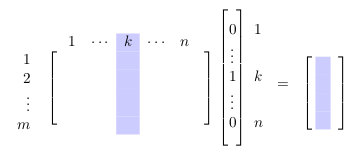)

$$m:\text{emb_dim}, \ n : \text{vocab_size}$$


In [ ]:
class Embedding(nn.Module):
    def __init__(self, vocab_size, emb_dim):
        super().__init__()
        # embedding_matrix：単語ごとのベクトルが詰まった大きな表
        # torch.randn()：最初は、全く意味のないランダムな数値が埋められている
        # ➡ 学習を経て、意味のある単語ベクトルへ
        self.embedding_matrix = nn.Parameter(
            torch.randn(
                (vocab_size, emb_dim),  # Generate random values from a Gaussian (normal) distribution
                dtype=torch.float
            )
        )

    # x：入力された「単語ID」
    def forward(self, x):
        # 入力されたIDをインデックスとして使い、該当する行のベクトルを抜き出す
        return F.embedding(x, self.embedding_matrix)

### 3.2. RNN

RNNクラスでは，Embedding層で各単語がベクトルに変換されたものを入力として処理を行います．ここで入力$\boldsymbol{x}$は

- $\boldsymbol{x}$: (ミニバッチサイズ) x (ミニバッチ内の文の最大系列長) x (単語のベクトルの次元数)

となっています．

ここでは `nn.Module` を用いてRNNクラスを定義します．

---

### 3.2. RNN

In the RNN class, we process the word vectors produced by the embedding layer. Here, the input $\mathbf{x}$ has shape:

- $\mathbf{x}$: (mini-batch size) × (maximum sequence length in the mini-batch) × (embedding dimension)

We define the RNN class using `nn.Module`.


In [ ]:
class RNN(nn.Module):
    def __init__(self, in_dim, hid_dim):
        super().__init__()
        self.hid_dim = hid_dim
        glorot = 6 / (in_dim + hid_dim * 2)
        self.W = nn.Parameter(torch.tensor(np.random.uniform(
            low=-np.sqrt(glorot),
            high=np.sqrt(glorot),
            size=(in_dim + hid_dim, hid_dim)
        ).astype('float32')))
        self.b = nn.Parameter(torch.tensor(np.zeros([hid_dim]).astype('float32')))

    def function(self, h, x):
        return torch.tanh(torch.matmul(torch.cat([h, x], dim=1), self.W) + self.b)

    def forward(self, x, len_seq_max=0, init_state=None):
        # For batched sequence processing, swap dimensions to (time, batch)
        x = x.transpose(0, 1)
        state = init_state

        # If no initial state is provided, initialise with zeros
        if init_state is None:
            state = torch.zeros((x[0].size()[0], self.hid_dim)).to(x.device)

        size = list(state.unsqueeze(0).size())
        size[0] = 0
        # Create an empty tensor first and then append outputs sequentially
        output = torch.empty(size, dtype=torch.float).to(x.device)

        if len_seq_max == 0:
            len_seq_max = x.size(0)
        for i in range(len_seq_max):
            state = self.function(state, x[i])
            output = torch.cat([output, state.unsqueeze(0)])  # Append output sequence
        return output

### 3.3. 分類器

---

### 3.3. Classifier


In [ ]:
# RNN
class SequenceTaggingNet(nn.Module):
    def __init__(self, word_num, emb_dim, hid_dim):
        super().__init__()
        self.emb = Embedding(word_num, emb_dim)
        self.rnn = RNN(emb_dim, hid_dim)
        self.linear = nn.Linear(hid_dim, 1)

    def forward(self, x, len_seq_max=0, len_seq=None, init_state=None):
        h = self.emb(x)  # WRITE ME
        h = self.rnn(h, len_seq_max, init_state)
        if len_seq is not None:
            # We need the output at the end of each sequence, so we gather it using len_seq
            h = h[len_seq - 1, list(range(len(x))), :]
        else:
            h = h[-1]
        y = self.linear(h)
        return y

### 3.4. 学習

---

### 3.4. Training


In [ ]:
emb_dim = 100
hid_dim = 50
n_epochs = 10
device = 'cuda'

net = SequenceTaggingNet(word_num, emb_dim, hid_dim)
net.to(device)

optimizer = optim.Adam(net.parameters())

train(net, optimizer, n_epochs)

EPOCH: 0, Train Loss: 0.687, Valid Loss: 0.676, Validation F1: 0.561
EPOCH: 1, Train Loss: 0.633, Valid Loss: 0.633, Validation F1: 0.642
EPOCH: 2, Train Loss: 0.589, Valid Loss: 0.585, Validation F1: 0.705
EPOCH: 3, Train Loss: 0.585, Valid Loss: 0.673, Validation F1: 0.451
EPOCH: 4, Train Loss: 0.599, Valid Loss: 0.614, Validation F1: 0.676
EPOCH: 5, Train Loss: 0.535, Valid Loss: 0.598, Validation F1: 0.687
EPOCH: 6, Train Loss: 0.490, Valid Loss: 0.583, Validation F1: 0.697
EPOCH: 7, Train Loss: 0.486, Valid Loss: 0.552, Validation F1: 0.736
EPOCH: 8, Train Loss: 0.479, Valid Loss: 0.578, Validation F1: 0.711
EPOCH: 9, Train Loss: 0.467, Valid Loss: 0.545, Validation F1: 0.750


### 3.5. `torch.nn.RNN`, `torch.nn.Embedding` を用いたネットワークの記述

`torch.nn.Conv2d`を用いてCNN層を容易に実装することができたように，`torch.nn.RNN`を用いることで容易にRNN層を実装することができます．

`torch.nn.RNN`は，系列データ $x$ と初期状態 $h_0$ を引数として受け取り，出力系列 $y$ と最終状態 $h$ を出力します．（`y, h = self.RNN(x, h_0)`）

また，少し厄介なことに`nn.RNN`の入力の系列データは，デフォルトで次元が [系列，ミニバッチ，各要素のベクトル] の順番となっています．しかしながら，データローダーが与えるデータは [ミニバッチ，系列，各要素] の順番となっており，この順番の方が直感的であると考えられます．これを解決するため，`torch.nn.RNN`は引数`batch_first`を受け取ることができ，これを`True`にすることで入力系列を [ミニバッチ，系列，各要素] の順番で受け取ることができます．

`batch_first=True`とすると出力の順番も入れ替わるので，`transpose`を用いて [系列，ミニバッチ，各要素のベクトル] としてから`len_seq`を元に最終出力を取り出します．

さらに，`torch.nn.RNN`は引数`num_layers`を持ち，RNNを何層重ねるかを指定します．多層に重ねることもできますが，ここでは課題2の実装と揃えるため一層とします．

また，`torch.nn.Embedding`を用いることでEmbedding層も容易に実装することができます．

---

### 3.5. Building a Network with `torch.nn.RNN` and `torch.nn.Embedding`

Just as `torch.nn.Conv2d` allows you to implement CNN layers easily, `torch.nn.RNN` allows you to implement an RNN layer with minimal code.

`torch.nn.RNN` takes a sequence input $x$ and an initial hidden state $h_0$, and outputs the sequence of outputs $y$ and the final hidden state $h$ (i.e., `y, h = self.RNN(x, h_0)`).

One caveat is that, by default, `nn.RNN` expects the input dimensions in the order **[sequence length, batch size, feature]**. However, the data loader typically provides data in the order **[batch size, sequence length, feature]**, which is often more intuitive. To handle this, `torch.nn.RNN` provides the `batch_first` argument; setting `batch_first=True` makes it accept inputs in **[batch, sequence, feature]** order.

When `batch_first=True`, the output order changes accordingly, so we use `transpose` to convert it back to **[sequence, batch, feature]**, and then use `len_seq` to extract the final output for each sequence.

`torch.nn.RNN` also has the `num_layers` argument to specify how many RNN layers to stack. While stacking is possible, we use a single layer here to match the earlier implementation.

Similarly, `torch.nn.Embedding` makes it easy to implement the embedding layer.


In [ ]:
# nn.RNN
class SequenceTaggingNet2(nn.Module):
    def __init__(self, word_num, emb_dim, hid_dim):
        super().__init__()
        self.emb = nn.Embedding(word_num, emb_dim)  # Use nn.Embedding
        self.rnn = nn.RNN(emb_dim, hid_dim, 1, batch_first=True)  # Use nn.RNN
        self.linear = nn.Linear(hid_dim, 1)

    def forward(self, x, len_seq_max=0, len_seq=None, init_state=None):
        h = self.emb(x)  # WRITE ME
        if len_seq_max > 0:
            h, _ = self.rnn(h[:, 0:len_seq_max, :], init_state)
        else:
            h, _ = self.rnn(h, init_state)
        h = h.transpose(0, 1)
        if len_seq is not None:
            # We need the output at the end of each sequence, so we gather it using len_seq
            h = h[len_seq - 1, list(range(len(x))), :]
        else:
            h = h[-1]

        y = self.linear(h)  # WRITE ME

        return y

In [ ]:
emb_dim = 100
hid_dim = 50
n_epochs = 10
device = 'cuda'

net = SequenceTaggingNet2(word_num, emb_dim, hid_dim)
net.to(device)

optimizer = optim.Adam(net.parameters())

train(net, optimizer, n_epochs)

EPOCH: 0, Train Loss: 0.688, Valid Loss: 0.673, Validation F1: 0.577
EPOCH: 1, Train Loss: 0.655, Valid Loss: 0.631, Validation F1: 0.643
EPOCH: 2, Train Loss: 0.603, Valid Loss: 0.598, Validation F1: 0.686
EPOCH: 3, Train Loss: 0.574, Valid Loss: 0.600, Validation F1: 0.694
EPOCH: 4, Train Loss: 0.577, Valid Loss: 0.611, Validation F1: 0.682
EPOCH: 5, Train Loss: 0.547, Valid Loss: 0.579, Validation F1: 0.710
EPOCH: 6, Train Loss: 0.513, Valid Loss: 0.585, Validation F1: 0.702
EPOCH: 7, Train Loss: 0.524, Valid Loss: 0.685, Validation F1: 0.580
EPOCH: 8, Train Loss: 0.602, Valid Loss: 0.652, Validation F1: 0.615
EPOCH: 9, Train Loss: 0.561, Valid Loss: 0.632, Validation F1: 0.651


## 4.Long short-term memory (LSTM)

### 4.1. LSTM

実装する式は次のようになります．($\odot$は要素ごとの積)

- 入力ゲート: $\hspace{20mm}\boldsymbol{i}_t = \mathrm{\sigma} \left(\boldsymbol{W}_i \left[\begin{array}{c} \boldsymbol{x}_t \\ \boldsymbol{h}_{t-1} \end{array}\right] + \boldsymbol{b}_i\right)$
- 忘却ゲート: $\hspace{20mm}\boldsymbol{f}_t = \mathrm{\sigma} \left(\boldsymbol{W}_f \left[\begin{array}{c} \boldsymbol{x}_t \\ \boldsymbol{h}_{t-1} \end{array}\right] + \boldsymbol{b}_f\right)$  
- 出力ゲート: $\hspace{20mm}\boldsymbol{o}_t = \mathrm{\sigma} \left(\boldsymbol{W}_o \left[\begin{array}{c} \boldsymbol{x}_t \\ \boldsymbol{h}_{t-1} \end{array}\right] + \boldsymbol{b}_o\right)$  
- セル:　　　 $\hspace{20mm}\boldsymbol{c}_t = \boldsymbol{f}_t \odot \boldsymbol{c}_{t-1} + \boldsymbol{i}_t \odot \tanh \left(\boldsymbol{W}_c \left[\begin{array}{c} \boldsymbol{x}_t \\ \boldsymbol{h}_{t-1} \end{array}\right] + \boldsymbol{b}_c\right)$
- 隠れ状態: 　$\hspace{20mm}\boldsymbol{h}_t = \boldsymbol{o}_t \odot \tanh \left(\boldsymbol{c}_t \right)$

単純なRNNでは各ステップの関数の戻り値は隠れ状態のみ ($\boldsymbol{h}_t$) でしたが，LSTMではセル状態と隠れ状態の2つ ($\boldsymbol{c}_t, \boldsymbol{h}_t$) となるので注意してください．

---

### 4.1. LSTM

The equations to implement are as follows ($\odot$ denotes element-wise multiplication).

- Input gate: $\hspace{20mm}\boldsymbol{i}_t = \mathrm{\sigma} \left(\boldsymbol{W}_i \left[\begin{array}{c} \boldsymbol{x}_t \\ \boldsymbol{h}_{t-1} \end{array}\right] + \boldsymbol{b}_i\right)$
- Forget gate: $\hspace{20mm}\boldsymbol{f}_t = \mathrm{\sigma} \left(\boldsymbol{W}_f \left[\begin{array}{c} \boldsymbol{x}_t \\ \boldsymbol{h}_{t-1} \end{array}\right] + \boldsymbol{b}_f\right)$  
- Output gate: $\hspace{20mm}\boldsymbol{o}_t = \mathrm{\sigma} \left(\boldsymbol{W}_o \left[\begin{array}{c} \boldsymbol{x}_t \\ \boldsymbol{h}_{t-1} \end{array}\right] + \boldsymbol{b}_o\right)$  
- Cell state: $\hspace{20mm}\boldsymbol{c}_t = \boldsymbol{f}_t \odot \boldsymbol{c}_{t-1} + \boldsymbol{i}_t \odot \tanh \left(\boldsymbol{W}_c \left[\begin{array}{c} \boldsymbol{x}_t \\ \boldsymbol{h}_{t-1} \end{array}\right] + \boldsymbol{b}_c\right)$
- Hidden state: $\hspace{20mm}\boldsymbol{h}_t = \boldsymbol{o}_t \odot \tanh \left(\boldsymbol{c}_t \right)$

In a simple RNN, the function at each step returns only the hidden state ($\boldsymbol{h}_t$).  
In an LSTM, however, it returns two states: the cell state and the hidden state ($\boldsymbol{c}_t, \boldsymbol{h}_t$). Keep this difference in mind.


In [ ]:
class LSTM(nn.Module):
    def __init__(self, in_dim, hid_dim):
        super().__init__()
        self.hid_dim = hid_dim
        glorot = 6 / (in_dim + hid_dim * 2)

        self.W_i = nn.Parameter(torch.tensor(np.random.uniform(
            low=-np.sqrt(glorot),
            high=np.sqrt(glorot),
            size=(in_dim + hid_dim, hid_dim)
        ).astype('float32')))
        self.b_i = nn.Parameter(torch.tensor(np.zeros([hid_dim]).astype('float32')))

        self.W_f = nn.Parameter(torch.tensor(np.random.uniform(
            low=-np.sqrt(glorot),
            high=np.sqrt(glorot),
            size=(in_dim + hid_dim, hid_dim)
        ).astype('float32')))
        self.b_f = nn.Parameter(torch.tensor(np.zeros([hid_dim]).astype('float32')))

        self.W_o = nn.Parameter(torch.tensor(np.random.uniform(
            low=-np.sqrt(glorot),
            high=np.sqrt(glorot),
            size=(in_dim + hid_dim, hid_dim)
        ).astype('float32')))
        self.b_o = nn.Parameter(torch.tensor(np.zeros([hid_dim]).astype('float32')))

        self.W_c = nn.Parameter(torch.tensor(np.random.uniform(
            low=-np.sqrt(glorot),
            high=np.sqrt(glorot),
            size=(in_dim + hid_dim, hid_dim)
        ).astype('float32')))
        self.b_c = nn.Parameter(torch.tensor(np.zeros([hid_dim]).astype('float32')))

    def function(self, state_c, state_h, x):
        i = torch.sigmoid(torch.matmul(torch.cat([state_h, x], dim=1), self.W_i) + self.b_i)  # WRITE ME
        f = torch.sigmoid(torch.matmul(torch.cat([state_h, x], dim=1), self.W_f) + self.b_f)  # WRITE ME
        o = torch.sigmoid(torch.matmul(torch.cat([state_h, x], dim=1), self.W_o) + self.b_o)  # WRITE ME
        c = f * state_c + i * torch.tanh(torch.matmul(torch.cat([state_h, x], dim=1), self.W_c) + self.b_c)  # WRITE ME
        h = o * torch.tanh(c)  # WRITE ME
        return c, h

    def forward(self, x, len_seq_max=0, init_state_c=None, init_state_h=None):
        # For batched sequence processing, swap dimensions to (time, batch)
        x = x.transpose(0, 1)
        state_c = init_state_c
        state_h = init_state_h

        # If no initial states are provided, initialise with zeros
        if init_state_c is None:
            state_c = torch.zeros((x[0].size()[0], self.hid_dim)).to(x.device)
        if init_state_h is None:
            state_h = torch.zeros((x[0].size()[0], self.hid_dim)).to(x.device)

        size = list(state_h.unsqueeze(0).size())
        size[0] = 0
        # Create an empty tensor first and then append outputs sequentially
        output = torch.empty(size, dtype=torch.float).to(x.device)

        if len_seq_max == 0:
            len_seq_max = x.size(0)
        for i in range(len_seq_max):
            state_c, state_h = self.function(state_c, state_h, x[i])
            output = torch.cat([output, state_h.unsqueeze(0)])  # Append output sequence
        return output

### 4.2. 分類器

---

### 4.2. Classifier


In [ ]:
# LSTM
class SequenceTaggingNet3(nn.Module):
    def __init__(self, word_num, emb_dim, hid_dim):
        super().__init__()
        self.emb = Embedding(word_num, emb_dim)
        self.lstm = LSTM(emb_dim, hid_dim)
        self.linear = nn.Linear(hid_dim, 1)

    def forward(self, x, len_seq_max=0, len_seq=None, init_state=None):
        h = self.emb(x)  # WRITE ME
        h = self.lstm(h, len_seq_max, init_state)  # WRITE ME
        if len_seq is not None:
            # We need the output at the end of each sequence, so we gather it using len_seq
            h = h[len_seq - 1, list(range(len(x))), :]
        else:
            h = h[-1]

        y = self.linear(h)  # WRITE ME

        return y

### 4.3. 学習

同じタスクを用いてRNNとLSTMの性能を比較します．

---

### 4.3. Training

We compare the performance of the RNN and the LSTM on the same task.


In [ ]:
emb_dim = 100
hid_dim = 50
n_epochs = 5
device = 'cuda'

net = SequenceTaggingNet3(word_num, emb_dim, hid_dim)
net.to(device)
optimizer = optim.Adam(net.parameters())

train(net, optimizer, n_epochs)

EPOCH: 0, Train Loss: 0.680, Valid Loss: 0.620, Validation F1: 0.656
EPOCH: 1, Train Loss: 0.545, Valid Loss: 0.534, Validation F1: 0.729
EPOCH: 2, Train Loss: 0.503, Valid Loss: 0.478, Validation F1: 0.781
EPOCH: 3, Train Loss: 0.399, Valid Loss: 0.437, Validation F1: 0.802
EPOCH: 4, Train Loss: 0.320, Valid Loss: 0.405, Validation F1: 0.829


### 4.4. `nn.LSTM`を用いたネットワークの記述

LSTMもRNNと同様に`nn.LSTM`を用いて実装することができます．

---

### 4.4. Building a Network with `nn.LSTM`

Like the RNN, an LSTM can be implemented using `nn.LSTM`.


In [ ]:
# nn.LSTM
class SequenceTaggingNet4(nn.Module):
    def __init__(self, word_num, emb_dim, hid_dim):
        super().__init__()
        self.emb = nn.Embedding(word_num, emb_dim)
        self.lstm = nn.LSTM(emb_dim, hid_dim, 1, batch_first=True)  # Use nn.LSTM
        self.linear = nn.Linear(hid_dim, 1)

    def forward(self, x, len_seq_max=0, len_seq=None, init_state=None):
        h = self.emb(x)
        if len_seq_max > 0:
            h, _ = self.lstm(h[:, 0:len_seq_max, :], init_state)
        else:
            h, _ = self.lstm(h, init_state)
        h = h.transpose(0, 1)
        if len_seq is not None:
            h = h[len_seq - 1, list(range(len(x))), :]
        else:
            h = h[-1]
        y = self.linear(h)

        return y

In [ ]:
emb_dim = 100
hid_dim = 50
n_epochs = 10
device = 'cuda'

net = SequenceTaggingNet4(word_num, emb_dim, hid_dim)
net.to(device)
optimizer = optim.Adam(net.parameters())

train(net, optimizer, n_epochs)

EPOCH: 0, Train Loss: 0.673, Valid Loss: 0.627, Validation F1: 0.634
EPOCH: 1, Train Loss: 0.536, Valid Loss: 0.505, Validation F1: 0.765
EPOCH: 2, Train Loss: 0.428, Valid Loss: 0.436, Validation F1: 0.811
EPOCH: 3, Train Loss: 0.354, Valid Loss: 0.427, Validation F1: 0.813
EPOCH: 4, Train Loss: 0.295, Valid Loss: 0.437, Validation F1: 0.814
EPOCH: 5, Train Loss: 0.253, Valid Loss: 0.437, Validation F1: 0.841
EPOCH: 6, Train Loss: 0.230, Valid Loss: 0.428, Validation F1: 0.832
EPOCH: 7, Train Loss: 0.188, Valid Loss: 0.441, Validation F1: 0.845
EPOCH: 8, Train Loss: 0.157, Valid Loss: 0.439, Validation F1: 0.839
EPOCH: 9, Train Loss: 0.170, Valid Loss: 0.507, Validation F1: 0.788


## 5.双方向LSTM（Bidirectional LSTM）

---

## 5. Bidirectional LSTM


### 5.1. 双方向LSTM

双方向LSTMでは，順方向にシークエンスを処理するLSTM（`self.forward_lstm`）と逆方向にシークエンスを処理するLSTM（`self.backward_lstm`）を別々に用意し，それぞれの出力を結合したものを全結合層へ渡します．  
これによりパラメータ数は増えますが，未来方向からの文脈も考慮した予測を行うことができるようになります．

[nn.LSTM](https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html)において`bidirectional=True`とするだけで実現できますが，ここではその処理を理解するために実装を行います．

- ここではこれまで`SequenceTaggingNet`として実装してきた分類器も含めて`BidirectionalLSTM`クラスとしています．（実装上どちらでも構いません）

---

### 5.1. Bidirectional LSTM

In a bidirectional LSTM, we prepare two separate LSTMs: one that processes the sequence forward (`self.forward_lstm`) and another that processes it backward (`self.backward_lstm`). We then concatenate their outputs and pass the result to a fully connected layer.

This increases the number of parameters, but enables predictions that incorporate context from both past and future directions.

While this can be achieved simply by setting `bidirectional=True` in [nn.LSTM](https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html), we implement it here to understand the underlying processing.

- Here, we define a `BidirectionalLSTM` class that includes the classifier that we previously implemented as `SequenceTaggingNet` (either design is fine for implementation).


In [ ]:
class BidirectionalLSTM(nn.Module):
    def __init__(self, word_num, emb_dim, hid_dim):
        super().__init__()
        # Prepare forward and backward LSTMs
        self.emb = nn.Embedding(word_num, emb_dim)
        self.forward_lstm = nn.LSTM(emb_dim, hid_dim, 1, batch_first=True)
        self.backward_lstm = nn.LSTM(emb_dim, hid_dim, 1, batch_first=True)
        self.linear = nn.Linear(hid_dim * 2, 1)  # x2 because we concatenate forward and backward outputs

    def forward(self, x, len_seq_max=0, len_seq=None, init_state=None):
        h = self.emb(x)  # (batch_size, seq_length, emb_dim)

        # Feed the reversed sequence to the backward LSTM
        if len_seq_max > 0:
            h1, _ = self.forward_lstm(h[:, 0:len_seq_max, :], init_state)
            h2, _ = self.backward_lstm(torch.flip(h[:, 0:len_seq_max, :], dims=[1]), init_state)
        else:
            h1, _ = self.forward_lstm(h)  # (batch_size, seq_length, hid_dim)
            h2, _ = self.backward_lstm(torch.flip(h, dims=[1]), init_state)  # (batch_size, seq_length, hid_dim)

        # Reverse the backward output again to restore the original order
        h2 = torch.flip(h2, dims=[1])

        # Concatenate the forward and backward outputs
        h = torch.cat([h1, h2], dim=2).transpose(0, 1)

        if len_seq is not None:
            h = h[len_seq - 1, list(range(len(x))), :]
        else:
            h = h[-1]

        y = self.linear(h)

        return y

### 5.2. 学習

双方向LSTMでも同じタスクを行います．

---

### 5.2. Training

We run the same task with the bidirectional LSTM as well.


In [ ]:
emb_dim = 100
hid_dim = 50
n_epochs = 10
device = 'cuda'

net = BidirectionalLSTM(word_num, emb_dim, hid_dim)
net.to(device)
optimizer = optim.Adam(net.parameters())

train(net, optimizer, n_epochs)

EPOCH: 0, Train Loss: 0.664, Valid Loss: 0.581, Validation F1: 0.699
EPOCH: 1, Train Loss: 0.530, Valid Loss: 0.483, Validation F1: 0.786
EPOCH: 2, Train Loss: 0.431, Valid Loss: 0.439, Validation F1: 0.801
EPOCH: 3, Train Loss: 0.385, Valid Loss: 0.419, Validation F1: 0.815
EPOCH: 4, Train Loss: 0.312, Valid Loss: 0.412, Validation F1: 0.814
EPOCH: 5, Train Loss: 0.271, Valid Loss: 0.399, Validation F1: 0.832
EPOCH: 6, Train Loss: 0.231, Valid Loss: 0.412, Validation F1: 0.831
EPOCH: 7, Train Loss: 0.206, Valid Loss: 0.442, Validation F1: 0.832
EPOCH: 8, Train Loss: 0.226, Valid Loss: 0.511, Validation F1: 0.755
EPOCH: 9, Train Loss: 0.204, Valid Loss: 0.432, Validation F1: 0.845


## 6.【補足】Gradient Clippingによる長系列への対処

LSTMは長系列に対しても学習がうまく行きやすいモデルでしたが，一般のRNNにおける長系列の学習の工夫として，**Gradient Clipping**に触れておきます．

RNNでは誤差逆伝播法が特に **Back Propagation Through Time (BPTT)** と呼ばれるものになり，各層のみならず各時点の勾配が乗算されます．

そのため，通常よりも勾配が過大（或いは過小）になりやすいという特徴をもっています．

こうした現象を **勾配爆発（消失）** と呼びますが，勾配爆発は学習を不安定化し収束を困難にします．

---

## 6. Supplement: Handling Long Sequences with Gradient Clipping

LSTMs tend to train well even on long sequences, but as a common technique for training standard RNNs on long sequences, we briefly introduce **Gradient Clipping**.

In RNNs, backpropagation becomes **Back Propagation Through Time (BPTT)**, where gradients are multiplied across not only layers but also time steps.

As a result, gradients can easily become excessively large (or extremely small) compared to usual training.

This phenomenon is known as **exploding (or vanishing) gradients**. Exploding gradients make training unstable and can prevent convergence.

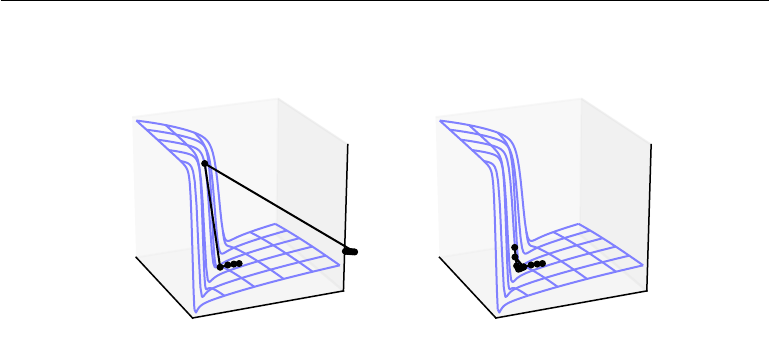

出典：Ian Goodfellow et. al, “Deep Learning”, MIT press, 2016 (http://www.deeplearningbook.org/)

そこで，勾配の大きさを意図的に制限して対処しようというのが，Gradient Clippingと呼ばれる手法です．

以下のように，`torch.nn.utils.clip_grad_norm_(parameters, max_norm)`を用いることで勾配をclippingすることができます．

この関数はparametersにmodelのパラメータ，max_normに勾配の絶対値の最大値を取ることで用いることができます．

---

Source: Ian Goodfellow et al., *Deep Learning*, MIT Press, 2016 (http://www.deeplearningbook.org/)

To address this, one common approach is to deliberately limit the magnitude of gradients—this technique is called **gradient clipping**.

As shown below, you can clip gradients using `torch.nn.utils.clip_grad_norm_(parameters, max_norm)`.

In this function, `parameters` refers to the model parameters, and `max_norm` specifies the maximum allowed norm (magnitude) of the gradients.


In [ ]:
def train_gradient_clipping(net, optimizer, n_epochs,
):
    for epoch in range(n_epochs):
        losses_train = []
        losses_valid = []

        net.train()
        n_train = 0
        acc_train = 0
        for label, line, len_seq in train_dataloader:

            net.zero_grad()

            t = label.to(device)  # Move tensors to GPU
            x = line.to(device)  # (batch, time)
            len_seq.to(device)

            h = net(x, torch.max(len_seq), len_seq)
            y = torch.sigmoid(h).squeeze()

            loss = -torch.mean(t * torch_log(y) + (1 - t) * torch_log(1 - y))

            loss.backward()

            # Clip gradients with max norm 1.0
            torch.nn.utils.clip_grad_norm_(net.parameters(), 1.0)

            optimizer.step()

            losses_train.append(loss.tolist())

            n_train += t.size()[0]

        t_valid = []
        y_pred = []
        net.eval()
        for label, line, len_seq in valid_dataloader:

            t = label.to(device)  # Move tensors to GPU
            x = line.to(device)  # (batch, time)
            len_seq.to(device)

            h = net(x, torch.max(len_seq), len_seq)
            y = torch.sigmoid(h).squeeze()

            loss = -torch.mean(t * torch_log(y) + (1 - t) * torch_log(1 - y))

            pred = y.round().squeeze()

            t_valid.extend(t.tolist())
            y_pred.extend(pred.tolist())

            losses_valid.append(loss.tolist())

        print('EPOCH: {}, Train Loss: {:.3f}, Valid Loss: {:.3f}, Validation F1: {:.3f}'.format(
            epoch,
            np.mean(losses_train),
            np.mean(losses_valid),
            f1_score(t_valid, y_pred, average='macro')
        ))

In [ ]:
emb_dim = 100
hid_dim = 50
n_epochs = 10
device = 'cuda'

net = SequenceTaggingNet2(word_num, emb_dim, hid_dim)
net.to(device)
optimizer = optim.Adam(net.parameters())

train_gradient_clipping(net, optimizer, n_epochs)

EPOCH: 0, Train Loss: 0.686, Valid Loss: 0.671, Validation F1: 0.572
EPOCH: 1, Train Loss: 0.634, Valid Loss: 0.611, Validation F1: 0.667
EPOCH: 2, Train Loss: 0.565, Valid Loss: 0.564, Validation F1: 0.719
EPOCH: 3, Train Loss: 0.514, Valid Loss: 0.572, Validation F1: 0.720
EPOCH: 4, Train Loss: 0.474, Valid Loss: 0.515, Validation F1: 0.763
EPOCH: 5, Train Loss: 0.439, Valid Loss: 0.522, Validation F1: 0.768
EPOCH: 6, Train Loss: 0.411, Valid Loss: 0.499, Validation F1: 0.776
EPOCH: 7, Train Loss: 0.384, Valid Loss: 0.505, Validation F1: 0.788
EPOCH: 8, Train Loss: 0.362, Valid Loss: 0.526, Validation F1: 0.772
EPOCH: 9, Train Loss: 0.329, Valid Loss: 0.531, Validation F1: 0.783
